# AG3 - Actividad Guiada 3
Nombre: Fabián Jesús Huarcaya Huaman <br>
Link:   https://colab.research.google.com/drive/xxxxxxxxxxxxxxxxxxxxxxxxx <br>
Github: https://github.com/xxxxx/AlgoritmosOptimizacion
<br>


# Carga de librerias

In [1]:
!pip install requests
!pip install tabulate>=0.9 networkx>=3.0
!pip install tsplib95 --no-deps
!pip install deprecated

In [2]:
!pip install deprecated

# Carga de los datos del problema
Preparación para trabajar con el problema del viajero (TSP)

In [3]:
import urllib.request #Hacer llamadas http a paginas de la red
import tsplib95       #Modulo para las instancias del problema del TSP
import math           #Modulo de funciones matematicas. Se usa para exp
import random         #Para generar valores aleatorios


#Descargamos el fichero de datos(Matriz de distancias)
file = "swiss42.tsp" ;
#urllib.request.urlretrieve("https://raw.githubusercontent.com/mastqe/tsplib/refs/heads/master/swiss42.tsp", file + '.gz')
urllib.request.urlretrieve("https://raw.githubusercontent.com/mastqe/tsplib/refs/heads/master/swiss42.tsp", file  )
#!gzip -d swiss42.tsp.gz     #Descomprimir el fichero de datos

#Coordendas 51-city problem (Christofides/Eilon)
# file = "eil51.tsp" ; urllib.request.urlretrieve("http://comopt.ifi.uni-heidelberg.de/software/TSPLIB95/tsp/eil51.tsp.gz", file)

#Coordenadas - 48 capitals of the US (Padberg/Rinaldi)
# file = "att48.tsp" ; urllib.request.urlretrieve("http://comopt.ifi.uni-heidelberg.de/software/TSPLIB95/tsp/att48.tsp.gz", file)


#http://comopt.ifi.uni-heidelberg.de/software/TSPLIB95
#Documentacion :
  # http://comopt.ifi.uni-heidelberg.de/software/TSPLIB95/tsp95.pdf
  # https://tsplib95.readthedocs.io/en/stable/pages/usage.html
  # https://tsplib95.readthedocs.io/en/v0.6.1/modules.html
  # https://pypi.org/project/tsplib95/

('swiss42.tsp', <http.client.HTTPMessage at 0x2944cdd0e50>)

In [4]:
#Carga de datos y generación de objeto problem
###############################################################################

# 1. Lectura del archivo
problem = tsplib95.load(file)

# Nodos: Ciudades del problema
Nodos = list(problem.get_nodes())

# Aristas: Todas las posibles comunicaciones entre ciudades
Aristas = list(problem.get_edges())

In [5]:
print(Nodos)
print(Aristas[:10])
# https://github.com/mastqe/tsplib/blob/master/swiss42.tsp

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41]
[(0, 0), (0, 1), (0, 2), (0, 3), (0, 4), (0, 5), (0, 6), (0, 7), (0, 8), (0, 9)]



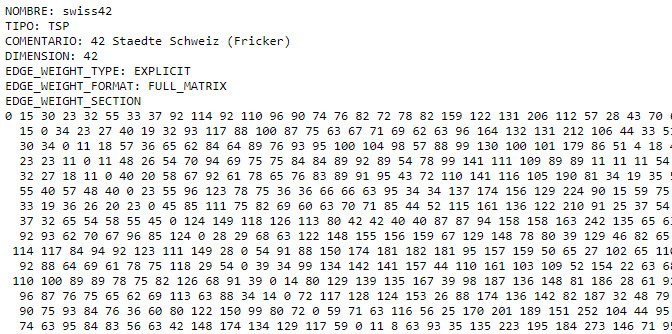

In [6]:
#Probamos algunas funciones del objeto problem

#Distancia entre nodos
problem.get_weight(3, 0)

#Todas las funciones
#Documentación: https://tsplib95.readthedocs.io/en/v0.6.1/modules.html

#dir(problem)

23

# Funciones basicas


In [7]:
#Funciones basicas
###############################################################################

# Se genera una solucion aleatoria con comienzo en en el nodo 0
def crear_solucion(Nodos):
    comienzo = [Nodos[0]]
    solucion = Nodos[1:].copy()
    random.shuffle(solucion) # Se mezclan de forma aleatoria todos los nodos menos el primero
    solucion = comienzo + solucion
    return solucion

# Devuelve la distancia entre dos nodos(ciudades)
def distancia(a,b, problem):
    return problem.get_weight(a,b)

# Devuelve la distancia total de una trayectoria/solucion
def distancia_total(solucion, problem):
    total = 0
    n = len(solucion)
    for i in range(n):
        total += problem.get_weight(solucion[i], solucion[(i+1) % n])
    return total


sol_temporal = crear_solucion(Nodos)


print(sol_temporal)
print(distancia_total(sol_temporal, problem))

[0, 23, 38, 11, 30, 27, 10, 3, 26, 4, 28, 7, 19, 9, 33, 17, 14, 20, 18, 37, 15, 25, 40, 8, 1, 16, 39, 12, 2, 29, 31, 13, 21, 35, 34, 5, 24, 36, 6, 32, 22, 41]
4956


# BUSQUEDA ALEATORIA

In [8]:
###############################################################################
# BUSQUEDA ALEATORIA
###############################################################################

def busqueda_aleatoria(problem, N):
    '''
    Esta función crea muchas soluciones aleatorias y se queda con la mejor
    problem: El problema con el que se trabaja
    N: Nº de iteraciones
    '''
    #N es el numero de iteraciones
    Nodos = list(problem.get_nodes())

    mejor_solucion = None
    mejor_distancia = float('inf')                      # Inicializamos con un valor alto

    for _ in range(N):                                  # Criterio de parada: repetir N veces pero podemos incluir otros
        solucion = crear_solucion(Nodos)                # Genera una solucion aleatoria
        distancia = distancia_total(solucion, problem)  # Calcula el valor objetivo(distancia total)

        if distancia < mejor_distancia:                 # Compara con la mejor obtenida hasta ahora
            mejor_solucion = solucion
            mejor_distancia = distancia


    print("Mejor solución:" , mejor_solucion)
    print("Distancia     :" , mejor_distancia)
    return mejor_solucion


#Busqueda aleatoria con 5000 iteraciones
solucion = busqueda_aleatoria(problem, 5000)
solucion = busqueda_aleatoria(problem, 5000)

Mejor solución: [0, 14, 3, 2, 10, 26, 28, 34, 20, 17, 7, 16, 19, 13, 5, 25, 4, 18, 21, 9, 22, 38, 33, 39, 32, 6, 1, 31, 8, 41, 40, 35, 37, 23, 36, 15, 11, 12, 24, 29, 30, 27]
Distancia     : 3597
Mejor solución: [0, 17, 8, 40, 39, 3, 36, 26, 30, 38, 20, 34, 19, 13, 1, 27, 7, 14, 15, 31, 6, 32, 5, 29, 41, 25, 9, 23, 28, 16, 37, 2, 33, 35, 18, 11, 21, 24, 10, 22, 12, 4]
Distancia     : 3620


# BUSQUEDA LOCAL

### Función auxiliar

In [9]:
###############################################################################
# BUSQUEDA LOCAL(1 paso)
###############################################################################
# El vecindario de una solución es solo el conjunto de soluciones que se pueden obtener aplicando 
# una pequeña modificación a la solución actual.

def genera_vecina(solucion,problem):
    '''
    Esta función genera todas las soluciones vecinas de una solución dada intercambiando pares de nodos (movimiento swap).
    Evalúa la distancia total de cada vecina y devuelve la que tiene menor distancia.
    El nodo inicial se mantiene fijo para evitar soluciones equivalentes por rotación.
    '''
    mejor_solucion = None
    mejor_distancia = float('inf')
    n = len(solucion)
    # Recorremos todos los nodos en bucle doble para evaluar todos los intercambios 2-opt
    for i in range(1,n-1): # O(n)   
        for j in range(i+1, n): # O(n)
            # Se genera una nueva solución intercambiando los dos nodos i,j: =O(n)
            vecina = solucion[:]
            vecina[i], vecina[j] = vecina[j], vecina[i]

            # Se evalua la nueva solución ... O(n)
            dist = distancia_total(vecina, problem)

            # ... para guardarla si mejora las anteriores
            if dist <= mejor_distancia:
                mejor_distancia = dist
                mejor_solucion = vecina
    return mejor_solucion
# La función es de orden O(n^3)




# Se puede introducir otra solución, en caso contrario se utiliza la del apartado anterior.
print("Distancia Solucion Incial:" , distancia_total(solucion, problem))
nueva_solucion = genera_vecina(solucion,problem)
print("Distancia Mejor Solucion Local:", distancia_total(nueva_solucion, problem))


Distancia Solucion Incial: 3620
Distancia Mejor Solucion Local: 3356


### Función principal

In [10]:
#Busqueda Local(iteraciones):
#  - Sobre el operador de vecindad 2-opt(funcion genera_vecina)
#  - Sin criterio de parada, se para cuando no es posible mejorar.

#Generar una solucion inicial de referencia(aleatoria)
#solucion_referencia = crear_solucion(Nodos)
def busqueda_local(solucion, problem):
    mejor_solucion = []

    solucion_referencia = solucion
    mejor_distancia = distancia_total(solucion_referencia, problem)

    iteracion=0             # Contador para saber las iteraciones que hacemos
    while(1):
        iteracion += 1         #Incrementamos el contador

        # Obtenemos la mejor vecina
        vecina = genera_vecina(solucion_referencia,problem)
        distancia_vecina = distancia_total(vecina, problem)

        # Si mejora, guardamos y continuamos
        if distancia_vecina < mejor_distancia:
            mejor_solucion = vecina                  
            mejor_distancia = distancia_vecina

        # Si no mejoramos, terminamos. Hemos llegado a un minimo local(según nuestro operador de vencindad 2-opt)
        else:
            print("En la iteracion ", iteracion, ", la mejor solución encontrada es:" , mejor_solucion)
            print("Distancia     :" , mejor_distancia)
            return mejor_solucion

        solucion_referencia = vecina


sol = busqueda_local(solucion, problem )

En la iteracion  36 , la mejor solución encontrada es: [0, 2, 8, 9, 39, 29, 30, 28, 32, 20, 33, 34, 27, 3, 4, 1, 37, 15, 16, 14, 19, 13, 26, 18, 25, 41, 23, 10, 5, 7, 17, 31, 36, 35, 38, 22, 21, 24, 40, 11, 12, 6]
Distancia     : 1909


## Propuesta de mejora
En el código original, la forma de generar soluciones vecinas es realizando intercambios de posiciones, es decir, realizar un *swap*.

Una forma de mejorar esta limitación es añadir dos funciones que generen entornos de forma distinta, de este modo se amplía el número de entornos construidos aumentando las probabilidades de encontrar uno que mejore la solución dada en ese momento.

Para ampliar los entornos, se utilizaran los siguientes métodos para modificar soluciones:
* *Inserción*
* *Reverse*

### Funciones auxiliares

In [11]:
def genera_vecina_insercion(solucion, problem):
    '''
    Esta función genera todas las soluciones vecinas moviendo un nodo de una posición a otra (movimiento inserción).
    Evalúa la distancia total de cada vecina y devuelve la que tiene menor distancia.
    El nodo inicial se mantiene fijo para evitar soluciones equivalentes por rotación.
    '''
    mejor_solucion = None
    mejor_distancia = float('inf')
    n = len(solucion)

    # Recorremos todos los nodos en bucle doble para evaluar todos los movimientos de inserción
    for i in range(1, n): # O(n)
        for j in range(1, n): # O(n)

            if i != j:

                # Se genera una nueva solución moviendo el nodo j a la posición i  O(n)
                vecina = solucion[:]
                nodo = vecina.pop(j)
                vecina.insert(i, nodo)

                # Se evalua la nueva solución ... O(n)
                dist = distancia_total(vecina, problem)

                # ... para guardarla si mejora las anteriores
                if dist <= mejor_distancia:
                    mejor_distancia = dist
                    mejor_solucion = vecina

    return mejor_solucion
# La función es de orden O(n^3)

def genera_vecina_reverse(solucion, problem):
    '''
    Esta función genera todas las soluciones vecinas invirtiendo segmentos de la solución (movimiento reverse).
    Evalúa la distancia total de cada vecina y devuelve la que tiene menor distancia.
    El nodo inicial se mantiene fijo para evitar soluciones equivalentes por rotación.
    '''
    mejor_solucion = None
    mejor_distancia = float('inf')
    n = len(solucion)

    # Recorremos todos los nodos en bucle doble para evaluar todas las inversiones de segmentos
    for i in range(1, n-1): # O(n)
        for j in range(i+1, n): # O(n)

            # Se genera una nueva solución invirtiendo el segmento entre i y j  O(n)
            vecina = solucion[:]
            vecina[i:j+1] = reversed(vecina[i:j+1])

            # Se evalua la nueva solución ... O(n)
            dist = distancia_total(vecina, problem)

            # ... para guardarla si mejora las anteriores
            if dist <= mejor_distancia:
                mejor_distancia = dist
                mejor_solucion = vecina

    return mejor_solucion

# La función también es de orden O(n^3)

### Función principal

In [12]:
def busqueda_local_variable(solucion, problem,maxit=1000):
    '''
    Búsqueda local con entornos variables.
    Se utilizan distintos operadores de vecindad (swap, inserción y reverse).
    Si algún entorno mejora la solución actual, se acepta la mejora y se vuelve
    al primer entorno. Si ningún entorno mejora, el algoritmo termina.
    '''

    mejor_solucion = []
    solucion_referencia = solucion
    mejor_distancia = distancia_total(solucion_referencia, problem)

    # Lista de entornos de vecindad
    entornos = [genera_vecina, genera_vecina_insercion, genera_vecina_reverse]

    iteracion = 0             # Contador para saber las iteraciones que hacemos
    k = 0                     # Índice del entorno actual

    while k < len(entornos) and iteracion < maxit:

        iteracion += 1

        # Obtenemos la mejor vecina usando el entorno k
        f = entornos[k]
        vecina = f(solucion_referencia, problem)
        distancia_vecina = distancia_total(vecina, problem)

        # Si mejora, guardamos y volvemos al primer entorno
        if distancia_vecina < mejor_distancia:
            mejor_solucion = vecina
            mejor_distancia = distancia_vecina
            solucion_referencia = vecina
            k = 0

        # Si no mejora, probamos el siguiente entorno
        else:
            k += 1

    print("En la iteracion ", iteracion, ", la mejor solución encontrada es:", mejor_solucion)
    print("Distancia     :", mejor_distancia)
    return mejor_solucion


sol = busqueda_local_variable(solucion, problem )

# Mejora a la solución del primer algoritmo de búsqueda local

En la iteracion  93 , la mejor solución encontrada es: [0, 32, 34, 33, 20, 35, 36, 31, 17, 7, 37, 15, 16, 14, 19, 13, 5, 26, 18, 12, 11, 25, 10, 8, 41, 23, 9, 21, 40, 24, 39, 22, 38, 30, 29, 28, 2, 27, 3, 4, 6, 1]
Distancia     : 1273


# SIMULATED ANNEALING

### Función original

In [13]:
###############################################################################
# SIMULATED ANNEALING
###############################################################################

# Generador de 1 solucion vecina 2-opt 100% aleatoria (intercambiar 2 nodos)
# Mejorable eligiendo otra forma de elegir una vecina.

def genera_vecina_aleatorio(solucion):
    '''
    Genera una solución vecina aleatoria intercambiando dos nodos (swap).
    Se usa para explorar el vecindario de forma estocástica.
    '''
    #Se eligen dos nodos aleatoriamente
    i,j = sorted(random.sample( range(1,len(solucion)) , 2))
    vecina = solucion[:]
    solucion[i], solucion[j] = solucion[j], solucion[i]
    
    #Devuelve una nueva solución pero intercambiando los dos nodos elegidos al azar
    return solucion


# Funcion de probabilidad para aceptar peores soluciones
# Sirve para salir de mínimos globales
def probabilidad(T,d):
    '''
    Calcula la probabilidad de aceptar una solución peor según Simulated Annealing.
    Cuanto mayor sea la temperatura T o menor el empeoramiento d, mayor probabilidad de aceptación.
    '''
    if random.random() <  math.exp( -1*d / T)  :
        return True
    else:
        return False

#Funcion de descenso de temperatura
# Sirve para disminuir la probabilidad de aceptar peores soluciones
def bajar_temperatura(T):
    return T*0.99

## Propuesta de mejora
Al igual que se ha hecho en el apartado anterior, para mejorar el número de posibles soluciones vecinas, se va a crear una nueva función `genera_vecina_aleatorio` para incluir los métodos del apartado anterior: *inserción* y *reverse*.

En la función principal se ha añadido el parámetro **moiriginal**. Si se indica como *True*, la función para generar vecinos será la original y si es *False*, se utilizará la nueva función. 

### Función auxiliar

In [14]:
def genera_vecina_aleatorio_mejorada(solucion):
    '''
    Esta función genera una solución vecina aleatoria utilizando distintos operadores
    de vecindad (swap, inserción y reverse). En cada llamada se selecciona aleatoriamente
    uno de los operadores para generar la nueva solución.
    El nodo inicial se mantiene fijo para evitar soluciones equivalentes por rotación.
    '''

    n = len(solucion)
    vecina = solucion[:]

    # Elegimos aleatoriamente el operador de vecindad
    operador = random.choice(["swap", "insercion", "reverse"])

    # Movimiento swap (intercambio de dos nodos)
    if operador == "swap":
        i, j = sorted(random.sample(range(1, n), 2))
        vecina[i], vecina[j] = vecina[j], vecina[i]

    # Movimiento inserción (mover un nodo a otra posición)
    elif operador == "insercion":
        i, j = sorted(random.sample(range(1, n), 2))
        nodo = vecina.pop(j)
        vecina.insert(i, nodo)

    # Movimiento reverse (invertir un segmento)
    elif operador == "reverse":
        i, j = sorted(random.sample(range(1, n), 2))
        vecina[i:j+1] = reversed(vecina[i:j+1])

    return vecina

### Función principal

In [15]:
def recocido_simulado(problem, T,moriginal=True):
    '''
    Implementa el algoritmo de Simulated Annealing para el TSP.
    Parte de una solución aleatoria y en cada iteración genera una vecina aleatoria.
    Si la vecina mejora la solución actual se acepta; si empeora, se acepta con una probabilidad dependiente de la temperatura.
    La temperatura se reduce progresivamente hasta que alcanza un valor mínimo.
    Se devuelve la mejor solución encontrada durante la búsqueda.
    El parámetro moriginal indica la función utilizada para generar entornos vecinos
    '''
    if moriginal:
        f = genera_vecina_aleatorio
    else:
        f = genera_vecina_aleatorio_mejorada
    
    
    Nodos = list(problem.get_nodes())
    
    # Solución incial aleatoria
    solucion_actual = crear_solucion(Nodos)
    distancia_actual = distancia_total(solucion_actual, problem)

    mejor_solucion = solucion_actual      
    mejor_distancia = distancia_actual       


    while T > .0001:
        
        # 1. Genera una solución vecina
        vecina = f(solucion_actual)
        distancia_vecina = distancia_total(vecina, problem)

        # 2. Comprobar si se acepta la solución
        delta = distancia_vecina - distancia_actual
        if delta < 0 or probabilidad(T,delta):
            mejor_solucion = vecina
            mejor_distancia = distancia_vecina

        # 3. Actualizamo si es mejor que solución global
        if distancia_vecina < mejor_distancia:
            mejor_solucion = vecina
            mejor_distancia = distancia_vecina

        # Bajamos la temperatura
        T = bajar_temperatura(T)

#     print("La mejor solución encontrada es " , end="")
#     print(mejor_solucion)
#     print("con una distancia total de " , end="")
#     print(mejor_distancia)
    return mejor_solucion,mejor_distancia

In [16]:
sol1,dist1  = recocido_simulado(problem, 10000000)
sol2,dist2  = recocido_simulado(problem, 10000000,moriginal=False)

print('================Solución con la función original==============')
print('Mejor solución encontrada',sol1)
print('Distancia',dist1)

print('================Solución con la función propuesta==============')
print('Mejor solución encontrada',sol2)
print('Distancia',dist2)

================Solución con la función original==============
Mejor solución encontrada [0, 17, 3, 11, 1, 36, 25, 37, 32, 16, 14, 23, 20, 13, 4, 8, 21, 6, 15, 5, 19, 7, 34, 24, 18, 27, 9, 28, 10, 41, 31, 33, 30, 12, 38, 22, 40, 29, 35, 2, 39, 26]
Distancia 4620
================Solución con la función propuesta==============
Mejor solución encontrada [0, 31, 18, 16, 21, 14, 20, 39, 38, 12, 8, 37, 32, 13, 30, 6, 28, 17, 33, 41, 19, 3, 40, 24, 29, 11, 27, 15, 23, 22, 26, 5, 1, 2, 9, 34, 35, 7, 10, 25, 4, 36]
Distancia 4752


# Representación en un grafo a partir de la matriz de distancias( Optimización de posiciones usando escalado multidimensional (MDS)



Multidimensional scaling problem(MDS):   https://en.wikipedia.org/wiki/Multidimensional_scaling

In [17]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from sklearn.manifold import MDS  # Multidimensional Scaling o Escalado Multidimensional

def plot_tsp_solution(distance_matrix, tsp_solution):
    """
    Dibuja la solución de un TSP usando MDS para posicionar los nodos.

    Parameters
    ----------
    distance_matrix : np.ndarray
        Matriz de distancias entre nodos.
    tsp_solution : list
        Orden de visita de los nodos en la solución TSP.
    """
    num_nodes = len(distance_matrix)

    # Calcular posiciones con MDS
    mds = MDS(n_components=2, dissimilarity="precomputed", random_state=42)
    coords = mds.fit_transform(distance_matrix)

    pos = {i: coords[i] for i in range(num_nodes)}

    # Crear grafo solo con las aristas del tour
    G = nx.Graph()

    for i in range(len(tsp_solution)):
        u = tsp_solution[i]
        v = tsp_solution[(i + 1) % len(tsp_solution)]  # cerrar el ciclo
        G.add_edge(u, v, weight=distance_matrix[u][v])

    plt.figure(figsize=(8,6))

    nx.draw_networkx_nodes(G, pos,
                           node_color="lightblue",
                           edgecolors="black",
                           node_size=400)

    nx.draw_networkx_edges(G, pos,
                           edge_color="red",
                           width=2)

    nx.draw_networkx_labels(G, pos, font_size=9)

    edge_labels = nx.get_edge_attributes(G, "weight")
    nx.draw_networkx_edge_labels(G, pos,
                                 edge_labels=edge_labels,
                                 font_size=7)

    plt.title("Solución del TSP")
    plt.axis("off")
    plt.show()

C:\Users\fabia\miniconda3\envs\notebooks\lib\site-packages\sklearn\manifold\_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


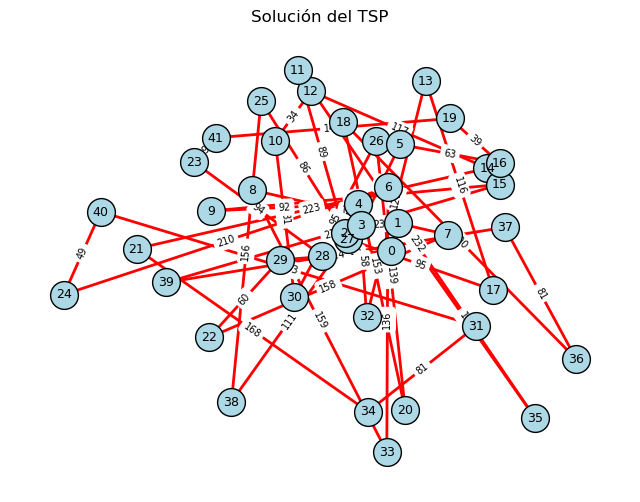

In [18]:
plot_tsp_solution(problem.edge_weights, crear_solucion(Nodos))

C:\Users\fabia\miniconda3\envs\notebooks\lib\site-packages\sklearn\manifold\_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


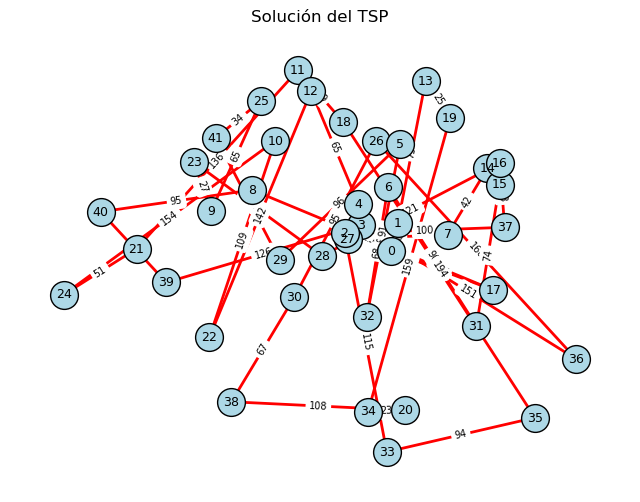

In [19]:
plot_tsp_solution(problem.edge_weights, solucion)